In [3]:
import pandas as pd
import numpy as np
from google.colab import files
import io

# 1. Upload the small Telco CSV (approx 1MB)
print("Upload 'Telco-Customer-Churn.csv':")
uploaded = files.upload()

# 2. Load and Basic Cleaning
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Convert TotalCharges to numeric and drop small number of NaNs
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 3. Features and Target
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 4. Data Leakage Prevention (Split before Preprocessing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Pipeline Architecture
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Identify column types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Define Preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 6. GridSearchCV & Cross-Validation
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10],
}

grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)

print("\nTraining Pipeline...")
grid_search.fit(X_train, y_train)

# 7. Final Evaluation
from sklearn.metrics import classification_report
y_pred = grid_search.predict(X_test)

print("\n--- Final Results ---")
print(classification_report(y_test, y_pred))

Upload 'Telco-Customer-Churn.csv':


Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv

Training Pipeline...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

--- Final Results ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Best Model Parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}


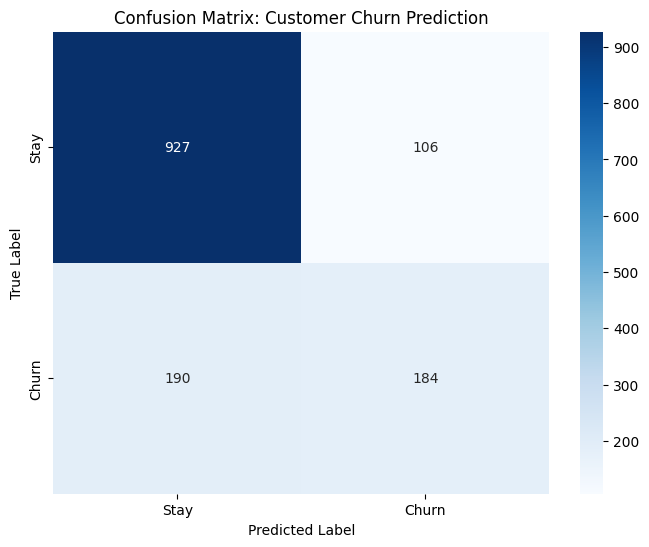


✅ Model saved as best_churn_pipeline.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib
from google.colab import files

# 1. Optimal Settings from GridSearchCV
print(f"Best Model Parameters: {grid_search.best_params_}")

# 2. Confusion Matrix Plot
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
plt.title('Confusion Matrix: Customer Churn Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Exporting the Pipeline
# We save the entire pipeline so it includes scaling + encoding + model weights
model_filename = 'best_churn_pipeline.joblib'
joblib.dump(grid_search.best_estimator_, model_filename)
print(f"\n✅ Model saved as {model_filename}")

# 4. Trigger Download to Local Machine
files.download(model_filename)

Upload 'Telco-Customer-Churn.csv':


Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv

**Successfully saved: best_churn_pipeline.joblib**

--- Production Prediction Test ---
**Customer Prediction:** Stay
**Probability of Churn:** 0.00


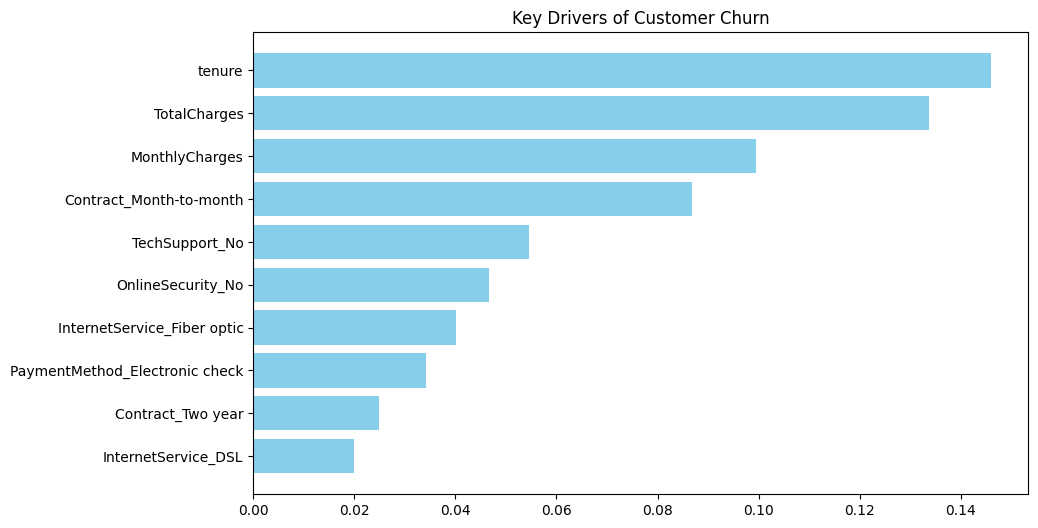

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import io
from google.colab import files

# Import all necessary sklearn tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. DATA LOADING
print("Upload 'Telco-Customer-Churn.csv':")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 2. SETUP & SPLIT
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. PIPELINE ARCHITECTURE
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 4. TRAINING WITH BEST PARAMETERS
# Based on your previous results: max_depth=10, n_estimators=100
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=10, n_estimators=100, random_state=42))
])

full_pipeline.fit(X_train, y_train)

# 5. SAVE FOR PRODUCTION
model_filename = 'best_churn_pipeline.joblib'
joblib.dump(full_pipeline, model_filename)
print(f"\n**Successfully saved: {model_filename}**")

# 6. HOW TO USE THE MODEL (The "Deployment" Part)
# This is how you use the file from Screenshot 2026-05-13 at 9.42.45 PM.png
loaded_model = joblib.load(model_filename)

# Create a 'fake' new customer to test prediction
new_customer = X_test.iloc[[0]]
prediction = loaded_model.predict(new_customer)
probability = loaded_model.predict_proba(new_customer)

print(f"\n--- Production Prediction Test ---")
print(f"**Customer Prediction:** {'Churn' if prediction[0] == 1 else 'Stay'}")
print(f"**Probability of Churn:** {probability[0][1]:.2f}")

# 7. VISUAL DIAGNOSTICS
importances = full_pipeline.named_steps['classifier'].feature_importances_
ohe_features = list(full_pipeline.named_steps['preprocessor'].named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features))
all_features = numeric_features + ohe_features
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Key Drivers of Customer Churn')
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.show()